# **Final Project Notebook**

### Zoe Kirkman & Madison Engebose

## **Research Question**
How do different features relate to burnout in technical workers that use AI for thier jobs?

## **Hypothesis**
1. Different remote work types have different levels of burnout.
2. Employees who spend more hours with AI assistance will experience higher burnout. 
3. More weekly AI upskilling hours are associated with lower burnout
4. High attrition risk increases burnout
5. Employees with higher fear of AI replacement have higher burnout scores. 

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import linregress, kruskal
from sklearn.preprocessing import MinMaxScaler


## **Dataset**
The dataset we are using looks at features related to job type and function, AI use within the job, and employee feelings about AI with respect to their jobs. The dataset was created synthetically using the patterns described in the following studies: Microsoft's 2025 Work Trend Index, Stack Overflow Developer Survey 2024-2025, Gallup Workplace Burnout Studies, LinkedIn Workforce Confidence Reports, and World Economic Forum Future of Jobs Report 2025.   
This dataset was created to gain insight into trends of AI use in the workplace and its impact on employees. 
It was created by Nudrat Abbas on Kaggle using the above studies. 
The target variable we chose to predict was burnout score for each employee. The features include information about each employee like job title, years of experience, education level, country, industry, salary, and team. There are other features related to the AI tool use including which tools they use, how many hours with the tool, their feelings about AI related to their jobs, and how much they improve their AI use skills. The last group of features includes score like productivity, job satisfaction, and attrition risk.

In [94]:
df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')
df.head(10)

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
5,EMP0006,Data Analyst,12,Self-taught,Germany,Healthtech,Large (1000-5000),On-site,19,106,...,5,5.7,23,Optimizing,6.7,66,61,3.5,Medium,Low
6,EMP0007,AI Ethics Officer,12,PhD,USA,Gaming,Enterprise (5000+),Fully Remote,46,154,...,1,2.7,45,Optimizing,8.1,54,33,3.5,High,Low
7,EMP0008,Data Scientist,19,Bootcamp,Singapore,Consulting,Enterprise (5000+),Hybrid,44,54,...,7,4.7,46,Optimizing,9.1,43,57,2.9,Low,Medium
8,EMP0009,Data Analyst,6,Master,Germany,Fintech,Mid (200-1000),Hybrid,42,55,...,7,2.8,56,Experimenting,8.1,69,52,2.8,Low,Medium
9,EMP0010,Prompt Engineer,2,Bachelor,Netherlands,Gaming,Large (1000-5000),On-site,15,61,...,5,1.8,8,Optimizing,9.7,64,27,3.8,Medium,Low


In [95]:
df.dtypes

employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

## **Data Preprocessing**

There were no missing values in this dataset to handle. We did change the types of the categorical features to type category and for the categorical variables that had an inherent ordering, we added that as well to the dataframe. We scaled numerical features.

In [96]:
nominal_cats = [
    "job_role", "education_level", "country",
    "industry", "company_size", "remote_work_type", "primary_ai_tool",
]
for col in nominal_cats:
    df[col] = df[col].astype("category")

In [97]:
df["fear_of_ai_replacement"] = pd.Categorical(
    df["fear_of_ai_replacement"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["attrition_risk"] = pd.Categorical(
    df["attrition_risk"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["ai_adoption_stage"] = pd.Categorical(
    df["ai_adoption_stage"],
    categories=["Experimenting", "Integrating", "Optimizing", "AI-First"],
    ordered=True,
)

In [98]:
scaler = MinMaxScaler()

numerical_cols = df.select_dtypes(include="number").columns.tolist()
numerical_cols.remove("burnout_score")

scaled_values = scaler.fit_transform(df[numerical_cols])
scaled_numerical_df = pd.DataFrame(scaled_values, columns=numerical_cols, index=df.index)

scaled_df = df.copy()
scaled_df[numerical_cols] = scaled_numerical_df

In [99]:
scaled_df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,0.333333,PhD,India,Healthtech,Large (1000-5000),Fully Remote,0.127660,0.688995,...,0.000000,0.013333,0.432432,Experimenting,0.49,0.485714,58,0.459459,Low,Medium
1,EMP0002,DevOps Engineer,0.111111,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,0.851064,0.052632,...,0.333333,0.013333,0.986486,Experimenting,0.66,0.557143,47,0.621622,Medium,Medium
2,EMP0003,Prompt Engineer,0.111111,PhD,India,Automotive,Startup (<50),Hybrid,0.744681,0.693780,...,0.500000,0.466667,0.243243,Optimizing,0.58,0.357143,37,0.891892,High,Medium
3,EMP0004,Backend Engineer,0.944444,Master,Germany,Media,Mid (200-1000),Fully Remote,0.127660,0.435407,...,0.666667,0.493333,0.945946,Integrating,0.14,0.742857,67,0.459459,Low,Medium
4,EMP0005,AI Researcher,0.222222,Bachelor,India,E-commerce,Small (50-200),Fully Remote,0.404255,0.282297,...,1.000000,0.026667,0.756757,Experimenting,0.16,0.471429,54,0.621622,Medium,Medium


In [100]:
df.dtypes

employee_id                         object
job_role                          category
years_experience                     int64
education_level                   category
country                           category
industry                          category
company_size                      category
remote_work_type                  category
team_size                            int64
salary_usd_k                         int64
primary_ai_tool                   category
ai_tools_used_per_day                int64
hours_with_ai_assistance_daily     float64
ai_replaces_my_tasks_pct             int64
ai_adoption_stage                 category
weekly_ai_upskilling_hrs           float64
productivity_score                   int64
burnout_score                        int64
job_satisfaction_1_5               float64
fear_of_ai_replacement            category
attrition_risk                    category
dtype: object

## **Data Analysis and Visualization**

clustering for the target variable based on other features

In [101]:
pd.DataFrame(df.select_dtypes(include="number")).describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


In [102]:
pd.DataFrame(scaled_df.select_dtypes(include="number")).describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.497074,0.485376,0.481981,0.509333,0.497831,0.489847,0.498553,0.464905,50.057333,0.549928
std,0.303385,0.291119,0.285729,0.329005,0.286452,0.292679,0.291393,0.153242,11.437771,0.172079
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000
25%,0.222222,0.234043,0.244019,0.166667,0.253333,0.239865,0.240000,0.357143,42.000000,0.432432
50%,0.500000,0.489362,0.473684,0.500000,0.493333,0.472973,0.500000,0.457143,50.000000,0.540541
75%,0.777778,0.723404,0.717703,0.833333,0.746667,0.743243,0.750000,0.571429,58.000000,0.675676
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,86.000000,1.000000


### Correlation Heatmap

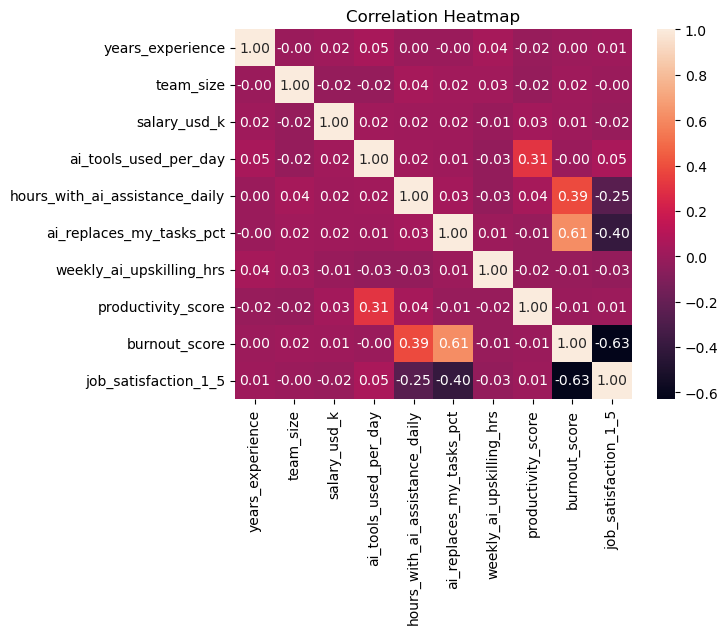

In [103]:
plt.figure()
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The chart suggests that higher burnout is strongly linked to lower job satisfaction and is moderately associated with factors like increased AI assistance and the belief that AI replaces tasks. This indicates that as burnout rises, satisfaction drops significantly, and certain AI-related experiences may be contributing to that burnout, while most demographic factors like salary or experience have little impact.

### Distribution of Burnout Scores

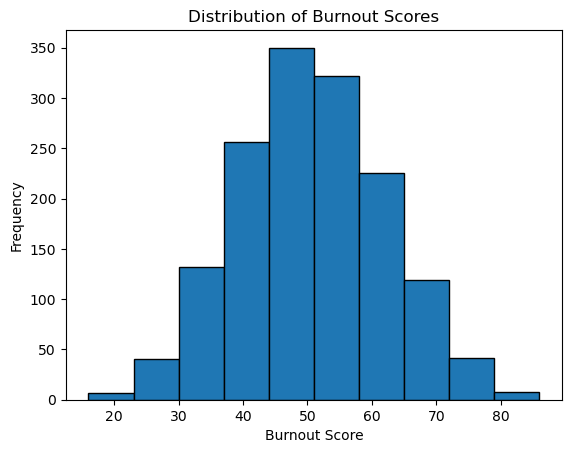

In [104]:
plt.hist(df["burnout_score"], edgecolor="black")
plt.title("Distribution of Burnout Scores")
plt.xlabel("Burnout Score")
plt.ylabel("Frequency")
plt.show()

The distribution of burnout scores appears roughly normal, with most values concentrated around the middle (around 45–60). There are relatively few very low or very high scores, suggesting that extreme burnout levels are less common in the dataset. Overall, burnout is fairly evenly spread.

### Distribution of Job Satisfaction

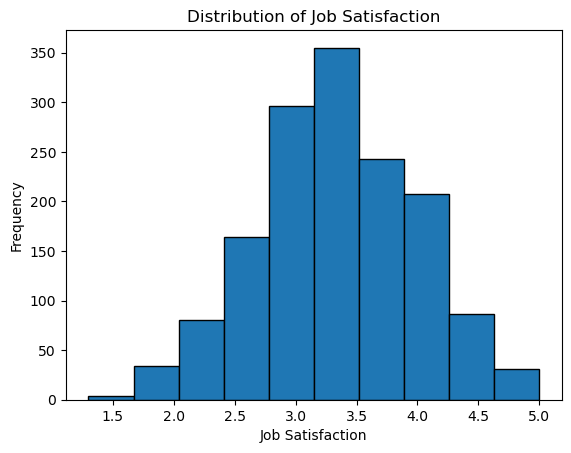

In [105]:
plt.hist(df["job_satisfaction_1_5"], edgecolor="black")
plt.title("Distribution of Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Frequency")
plt.show()

The distribution of job satisfaction is also roughly normal, centered around moderate values (around 3 to 3.5). Most responses fall in the middle range, with fewer people reporting very low or very high satisfaction.

### Distribution of AI Tools Used Per Day

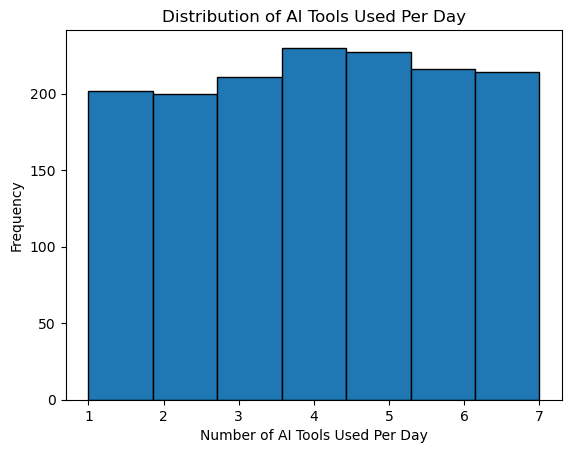

In [106]:
plt.hist(df["ai_tools_used_per_day"], bins=7, edgecolor="black")
plt.title("Distribution of AI Tools Used Per Day")
plt.xlabel("Number of AI Tools Used Per Day")
plt.ylabel("Frequency")
plt.show()

The distribution of AI tools used per day is fairly uniform, with values spread relatively evenly from 1 to 7. There isn’t a strong peak, suggesting that people in the dataset vary widely in how many AI tools they use daily, rather than clustering around a specific number.

### Distribution of Hours with AI Assistance Daily

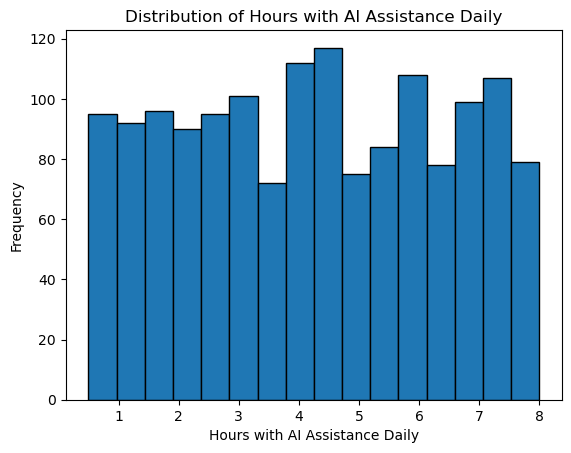

In [107]:
plt.hist(df["hours_with_ai_assistance_daily"], bins=16, edgecolor="black")
plt.title("Distribution of Hours with AI Assistance Daily")
plt.xlabel("Hours with AI Assistance Daily")
plt.ylabel("Frequency")
plt.show()

The distribution of hours with AI assistance daily is fairly evenly spread across the range, with no strong central peak. This suggests that people differ widely in how long they use AI each day, with usage distributed from low to high hours rather than concentrated around a typical value.

### Burnout by Remote Work Type

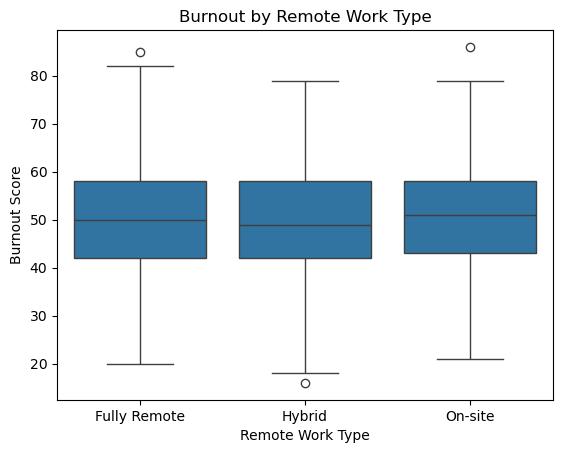

In [108]:
plt.figure()
sns.boxplot(x="remote_work_type", y="burnout_score", data=df)
plt.title("Burnout by Remote Work Type")
plt.xlabel("Remote Work Type")
plt.ylabel("Burnout Score")
plt.show()

The boxplot shows that burnout levels are fairly similar across all work types (fully remote, hybrid, and on-site), with medians clustered around the same range. There is some variability within each group and a few outliers, but no type clearly stands out as having significantly higher or lower burnout. Overall, remote work type does not appear to strongly influence burnout in this dataset.

### AI Replacing Tasks vs Burnout

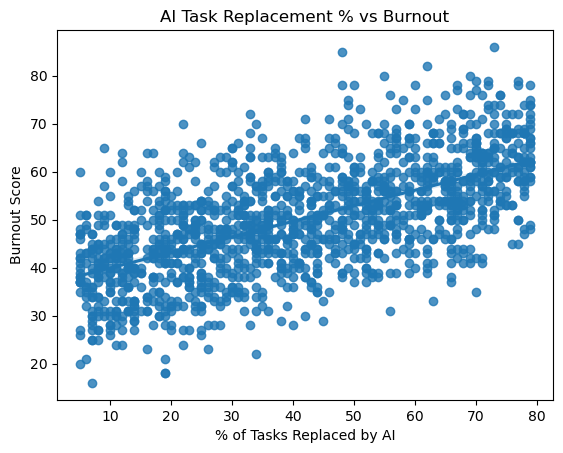

In [109]:
plt.figure()
sns.regplot(x="ai_replaces_my_tasks_pct", y="burnout_score", data=df)
plt.title("AI Task Replacement % vs Burnout")
plt.xlabel("% of Tasks Replaced by AI")
plt.ylabel("Burnout Score")
plt.show()

This scatterplot shows a clear positive relationship between AI task replacement and burnout. As the percentage of tasks replaced by AI increases, burnout scores tend to rise as well. While there is some spread in the data, the overall upward trend suggests that greater reliance on AI for task replacement is associated with higher levels of burnout.

### Daily AI Hours vs Burnout

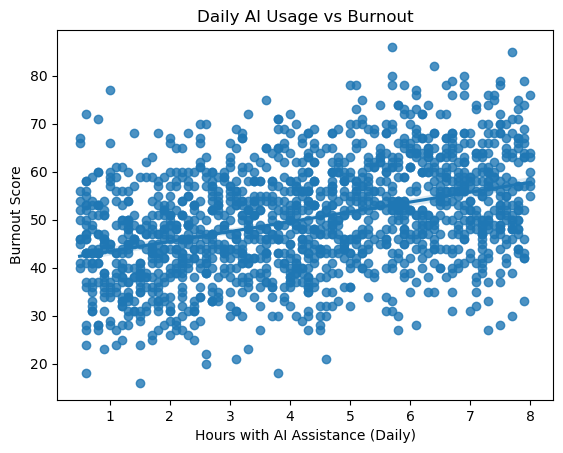

In [110]:
plt.figure()
sns.regplot(x="hours_with_ai_assistance_daily", y="burnout_score", data=df)
plt.title("Daily AI Usage vs Burnout")
plt.xlabel("Hours with AI Assistance (Daily)")
plt.ylabel("Burnout Score")
plt.show()

This scatterplot shows a moderate positive relationship between daily AI usage and burnout. As the number of hours using AI increases, burnout scores tend to rise slightly, though the data is fairly spread out. This suggests that higher daily reliance on AI is associated with increased burnout, but the relationship is not as strong as with AI task replacement.

### AI Upskilling vs Burnout

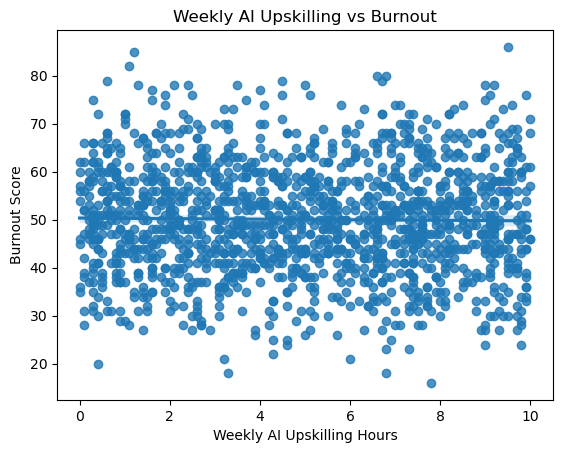

In [111]:
plt.figure()
sns.regplot(x="weekly_ai_upskilling_hrs", y="burnout_score", data=df)
plt.title("Weekly AI Upskilling vs Burnout")
plt.xlabel("Weekly AI Upskilling Hours")
plt.ylabel("Burnout Score")
plt.show()

This scatterplot shows little to no clear relationship between weekly AI upskilling hours and burnout. The data points are widely scattered with no strong upward or downward trend, suggesting that spending more time learning AI skills does not significantly impact burnout levels in this dataset.

### Fear of AI Replacement vs Burnout

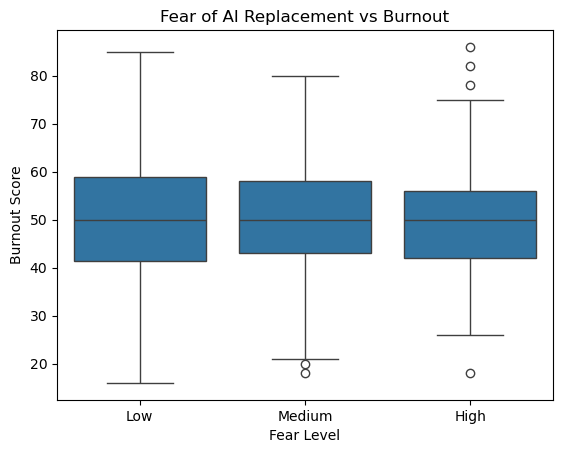

In [112]:
plt.figure()
sns.boxplot(x="fear_of_ai_replacement", y="burnout_score", data=df)
plt.title("Fear of AI Replacement vs Burnout")
plt.xlabel("Fear Level")
plt.ylabel("Burnout Score")
plt.show()

The boxplot shows that burnout levels are fairly similar across low, medium, and high fear of AI replacement, with medians clustered around the same range. While the high fear group shows slightly more variability and some higher outliers, there isn’t a strong or consistent increase in burnout across the categories. Overall, fear of AI replacement does not appear to create a clear difference in burnout levels in this dataset.

### Burnout vs Attrition Risk

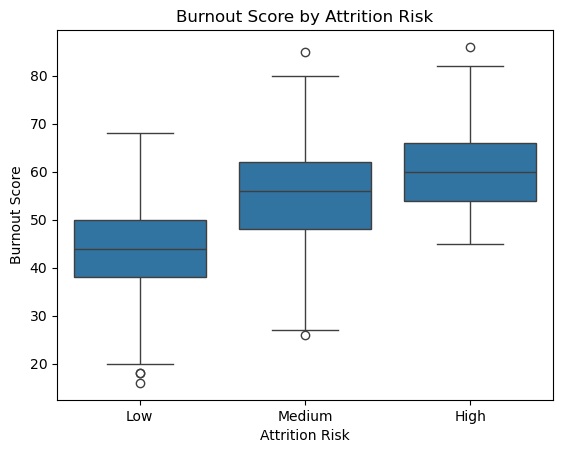

In [113]:
plt.figure()
sns.boxplot(x="attrition_risk", y="burnout_score", data=df)
plt.title("Burnout Score by Attrition Risk")
plt.xlabel("Attrition Risk")
plt.ylabel("Burnout Score")
plt.show()

This boxplot shows a clear positive relationship between burnout and attrition risk. As attrition risk increases from low to high, the median burnout score also rises noticeably. Employees with high attrition risk tend to have the highest burnout levels, suggesting that burnout is strongly associated with a greater likelihood of leaving.

### Productivity vs Burnout

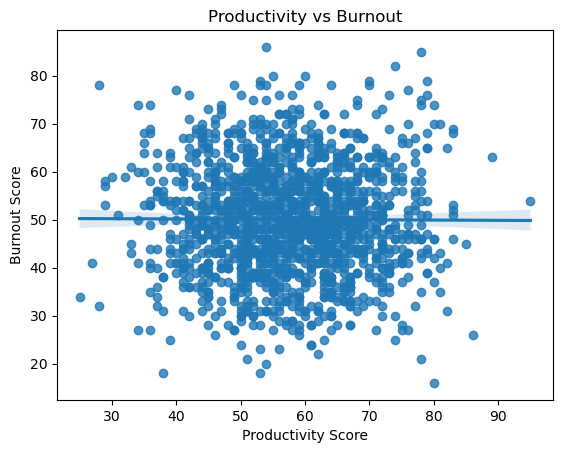

In [114]:
plt.figure()
sns.regplot(x="productivity_score", y="burnout_score", data=df)
plt.title("Productivity vs Burnout")
plt.xlabel("Productivity Score")
plt.ylabel("Burnout Score")
plt.show()

This scatterplot shows little to no meaningful relationship between productivity and burnout. The points are widely scattered and the trend line is nearly flat, indicating that changes in productivity are not strongly associated with changes in burnout in this dataset.

### Job Satisfaction vs Burnout

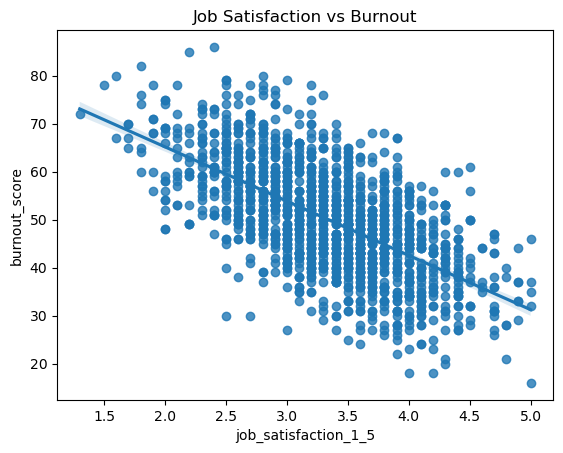

In [115]:
plt.figure()
sns.regplot(x="job_satisfaction_1_5", y="burnout_score", data=df)
plt.title("Job Satisfaction vs Burnout")
plt.show()

This scatterplot shows a strong negative relationship between job satisfaction and burnout. As job satisfaction increases, burnout scores decrease significantly. This suggests that employees who are more satisfied with their jobs tend to experience much lower levels of burnout.

## **Statistical Testing**

In [116]:
y_col = 'burnout_score'

numerical_predictors = ['years_experience', 'team_size', 'salary_usd_k',
                        'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
                        'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
                        'productivity_score', 'job_satisfaction_1_5']

categorical_predictors = ['job_role', 'education_level', 'country', 'industry',
                          'company_size', 'remote_work_type', 'primary_ai_tool',
                          'ai_adoption_stage', 'fear_of_ai_replacement', 'attrition_risk']

alpha = 0.05

### Pearson Correlation with Bonferonni Correction

In [117]:
results_linreg = []
total_tests = 68
bonf_alpha = alpha / total_tests

for x_col in numerical_predictors:
    tmp = df[[y_col, x_col]].dropna()
    lr = linregress(tmp[x_col], tmp[y_col])

    results_linreg.append({
        "predictor": x_col,
        "response": y_col,
        "test": "linregress (Pearson corr)",
        "statistic": lr.rvalue,
        "p_value": lr.pvalue,
        "bonferroni_alpha": bonf_alpha,
        "n": len(tmp),
        "significant": lr.pvalue < bonf_alpha,
    })

results_linreg

[{'predictor': 'years_experience',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(0.004534171615242385),
  'p_value': np.float64(0.8607164562337624),
  'bonferroni_alpha': 0.0007352941176470588,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'team_size',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(0.017170791880538938),
  'p_value': np.float64(0.5063597918443248),
  'bonferroni_alpha': 0.0007352941176470588,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'salary_usd_k',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(0.013117776396078664),
  'p_value': np.float64(0.6117005030611817),
  'bonferroni_alpha': 0.0007352941176470588,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'ai_tools_used_per_day',
  'response': 'burnout_score',
  'test': 'linregress (Pearson corr)',
  'statistic': np.float64(-0.00333329610406

### Kruskal Wallis with Bonferroni Correlation

In [118]:
results_kruskal = []
total_tests = 68
bonf_alpha = alpha / total_tests

for x_col in categorical_predictors:
    tmp = df[[y_col, x_col]].dropna()

    samples_by_group = []
    for value in set(tmp[x_col]):
        mask = tmp[x_col] == value
        samples_by_group.append(tmp[y_col][mask])

    stat, p = kruskal(*samples_by_group)

    results_kruskal.append({
        "predictor": x_col,
        "response": y_col,
        "test": "Kruskal-Wallis",
        "statistic": stat,
        "p_value": p,
        "bonferroni_alpha": bonf_alpha,
        "n": len(tmp),
        "significant": p < bonf_alpha,
    })

results_kruskal

[{'predictor': 'job_role',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(12.461977922767831),
  'p_value': np.float64(0.3299376086430897),
  'bonferroni_alpha': 0.0007352941176470588,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'education_level',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(11.128033480236818),
  'p_value': np.float64(0.02516215958927435),
  'bonferroni_alpha': 0.0007352941176470588,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'country',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(10.87588512102529),
  'p_value': np.float64(0.2843124568827608),
  'bonferroni_alpha': 0.0007352941176470588,
  'n': 1500,
  'significant': np.False_},
 {'predictor': 'industry',
  'response': 'burnout_score',
  'test': 'Kruskal-Wallis',
  'statistic': np.float64(3.2736379497360177),
  'p_value': np.float64(0.9524511883398616),
  'bonferroni_alpha':

### Results

**Bonferroni-corrected α = 0.05 / 68 ≈ 0.0007**

| Predictor | Test | Statistic (r or H) | p-value | Significant? |
|---|---|---|---|---|
| years_experience | Pearson (linregress) | 0.0045 | 0.8607 | No |
| team_size | Pearson (linregress) | 0.0172 | 0.5064 | No |
| salary_usd_k | Pearson (linregress) | 0.0131 | 0.6117 | No |
| ai_tools_used_per_day | Pearson (linregress) | -0.0033 | 0.8974 | No |
| hours_with_ai_assistance_daily | Pearson (linregress) | 0.3856 | 2.31e-54 | **Yes** |
| ai_replaces_my_tasks_pct | Pearson (linregress) | 0.6134 | 9.99e-156 | **Yes** |
| weekly_ai_upskilling_hrs | Pearson (linregress) | -0.0149 | 0.5650 | No |
| productivity_score | Pearson (linregress) | -0.0053 | 0.8368 | No |
| job_satisfaction_1_5 | Pearson (linregress) | -0.6293 | 3.04e-166 | **Yes** |
| job_role | Kruskal-Wallis | 12.462 | 0.3299 | No |
| education_level | Kruskal-Wallis | 11.128 | 0.0252 | No |
| country | Kruskal-Wallis | 10.876 | 0.2843 | No |
| industry | Kruskal-Wallis | 3.274 | 0.9525 | No |
| company_size | Kruskal-Wallis | 0.594 | 0.9638 | No |
| remote_work_type | Kruskal-Wallis | 1.586 | 0.4525 | No |
| primary_ai_tool | Kruskal-Wallis | 14.139 | 0.0488 | No |
| ai_adoption_stage | Kruskal-Wallis | 1.325 | 0.7232 | No |
| fear_of_ai_replacement | Kruskal-Wallis | 1.622 | 0.4444 | No |
| attrition_risk | Kruskal-Wallis | 420.194 | 5.70e-92 | **Yes** |

## **Data Modeling and Prediction**

### Baseline Linear Regression Model

sklearn baseline model using all numerical features:
train-test split is split 70/30

In [119]:
regression_model = LinearRegression()
independent_cols = pd.DataFrame(scaled_df.select_dtypes(include="number"))
independent_cols = independent_cols.drop("burnout_score", axis =1)
y = scaled_df["burnout_score"]

X_train, X_test, y_train, y_test = train_test_split(independent_cols, y, test_size=0.3, random_state=27)

results = regression_model.fit(X_train, y_train)
for i in range(len(X_train.columns)):
    print(f"{X_train.columns[i]}: {results.coef_[i]:.4f}")
    


years_experience: 0.7194
team_size: -0.1186
salary_usd_k: -0.3894
ai_tools_used_per_day: 0.4927
hours_with_ai_assistance_daily: 11.0537
ai_replaces_my_tasks_pct: 18.4992
weekly_ai_upskilling_hrs: -0.7157
productivity_score: -1.9034
job_satisfaction_1_5: -25.1027


### Linear Regression on All Features

Statsmodel API

This model uses all numerical values without any categorical variables being encoded

In [120]:
import statsmodels.api as sm

X = sm.add_constant(X_train)
linear_model = sm.OLS(y_train, X).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     198.6
Date:                Fri, 01 May 2026   Prob (F-statistic):          8.20e-219
Time:                        14:01:50   Log-Likelihood:                -3528.8
No. Observations:                1050   AIC:                             7078.
Df Residuals:                    1040   BIC:                             7127.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

**Corrected P-values**

In [121]:
adjusted_alpha = 0.05 / 68

results = linear_model.pvalues.to_frame(name="p_value")
results["significant"] = results["p_value"] < adjusted_alpha

print(results)

                                      p_value  significant
const                           1.670525e-161         True
years_experience                 3.127827e-01        False
team_size                        8.732870e-01        False
salary_usd_k                     6.051464e-01        False
ai_tools_used_per_day            4.770860e-01        False
hours_with_ai_assistance_daily   4.333052e-41         True
ai_replaces_my_tasks_pct         9.027248e-92         True
weekly_ai_upskilling_hrs         3.387146e-01        False
productivity_score               1.998233e-01        False
job_satisfaction_1_5             1.244145e-59         True


### Linear Regression Model with Only Significant Predictors
The following linear regression model only has the predictors that are statistically significant after applying bonferoni correction (alpha = )and it has the same ajusted R-squared value so the other variables were not helpful. 
This model uses hours_with_ai_assistance, ai_replaces_my_tasks_pct, job_satisfaction_1_5 as predictors 

In [122]:
significant_predictors = X_train.columns[linear_model.pvalues[1:] < (0.05 / 68)]
X = sm.add_constant(X_train[significant_predictors])
refined_model = sm.OLS(y_train, X).fit()
print(refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     595.4
Date:                Fri, 01 May 2026   Prob (F-statistic):          1.14e-225
Time:                        14:01:50   Log-Likelihood:                -3530.9
No. Observations:                1050   AIC:                             7070.
Df Residuals:                    1046   BIC:                             7090.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

**Corrected P-values**

In [123]:
adjusted_alpha = 0.05 / 68

results = refined_model.pvalues.to_frame(name="p_value")
results["significant"] = results["p_value"] < adjusted_alpha

print(results)

                                      p_value  significant
const                           1.049584e-219         True
hours_with_ai_assistance_daily   8.031133e-42         True
ai_replaces_my_tasks_pct         9.951796e-93         True
job_satisfaction_1_5             1.237004e-59         True


### One Hot Encoding 
Using one hot encoding to add categorical variables to be used in the linear regression model. Including education_level, remote_work_type, fear_of_ai_replacement, and attrition_risk

In [124]:
# One hot encoding education level 
scaled_df["formal_education"] = scaled_df["education_level"].apply(lambda x: 1 if x in ["Bachelor", "Masters", "PhD"] else 0)
scaled_df["masters_phd"] = scaled_df["education_level"].apply(lambda x: 1 if x in ["Masters", "PhD"] else 0)

# Remote work type encoding
scaled_df["is_hybrid"] = scaled_df["remote_work_type"].apply(lambda x: 1 if x == "Hybrid" else 0)
scaled_df["is_remote"] = scaled_df["remote_work_type"].apply(lambda x: 1 if x == "Remote" else 0)
scaled_df["is_on_site"] = scaled_df["remote_work_type"].apply(lambda x: 1 if x == "On Site" else 0)

# Fear of AI Replacement encoding
scaled_df["fear_low"] = scaled_df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "Low" else 0)
scaled_df["fear_medium"] = scaled_df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "Medium" else 0)
scaled_df["fear_high"] = scaled_df["fear_of_ai_replacement"].apply(lambda x: 1 if x == "High" else 0)

# Attrition risk encoding
scaled_df["attrition_low"] = scaled_df["attrition_risk"].apply(lambda x: 1 if x == "Low" else 0)
scaled_df["attrition_medium"] = scaled_df["attrition_risk"].apply(lambda x: 1 if x == "Medium" else 0)
scaled_df["attrition_high"] = scaled_df["attrition_risk"].apply(lambda x: 1 if x == "High" else 0)

scaled_df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,masters_phd,is_hybrid,is_remote,is_on_site,fear_low,fear_medium,fear_high,attrition_low,attrition_medium,attrition_high
0,EMP0001,Data Analyst,0.333333,PhD,India,Healthtech,Large (1000-5000),Fully Remote,0.127660,0.688995,...,1,0,0,0,1,0,0,0,1,0
1,EMP0002,DevOps Engineer,0.111111,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,0.851064,0.052632,...,0,1,0,0,0,1,0,0,1,0
2,EMP0003,Prompt Engineer,0.111111,PhD,India,Automotive,Startup (<50),Hybrid,0.744681,0.693780,...,1,1,0,0,0,0,1,0,1,0
3,EMP0004,Backend Engineer,0.944444,Master,Germany,Media,Mid (200-1000),Fully Remote,0.127660,0.435407,...,0,0,0,0,1,0,0,0,1,0
4,EMP0005,AI Researcher,0.222222,Bachelor,India,E-commerce,Small (50-200),Fully Remote,0.404255,0.282297,...,0,0,0,0,0,1,0,0,1,0


### One Hot Encoded Linear Regression on All Features

In [125]:
independent_cols = pd.DataFrame(scaled_df.select_dtypes(include="number"))
independent_cols = independent_cols.drop("burnout_score", axis =1)
y = scaled_df["burnout_score"]
X_train, X_test, y_train, y_test = train_test_split(independent_cols, y, test_size=0.3, random_state=27)


X = sm.add_constant(X_train)
one_hot_encoding_model = sm.OLS(y_train, X).fit()
print(one_hot_encoding_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     131.1
Date:                Fri, 01 May 2026   Prob (F-statistic):          2.65e-235
Time:                        14:01:50   Log-Likelihood:                -3471.8
No. Observations:                1050   AIC:                             6978.
Df Residuals:                    1033   BIC:                             7062.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

**Corrected P-values**

In [126]:
adjusted_alpha = 0.05 / 68

results = one_hot_encoding_model.pvalues.to_frame(name="p_value")
results["significant"] = results["p_value"] < adjusted_alpha

print(results)

                                      p_value  significant
const                           2.311806e-152         True
years_experience                 3.797048e-01        False
team_size                        9.536364e-01        False
salary_usd_k                     9.609155e-01        False
ai_tools_used_per_day            7.569691e-01        False
hours_with_ai_assistance_daily   6.701563e-39         True
ai_replaces_my_tasks_pct         1.056633e-79         True
weekly_ai_upskilling_hrs         3.324197e-01        False
productivity_score               2.977191e-01        False
job_satisfaction_1_5             8.518361e-17         True
formal_education                 9.801161e-02        False
masters_phd                      2.445505e-01        False
is_hybrid                        6.335321e-01        False
is_remote                        1.075741e-34         True
is_on_site                       3.030635e-29         True
fear_low                        1.447576e-107         Tr

### One Hot Encoded Linear Regression with Only Significant Predictors

In [127]:
significant_predictors = X_train.columns[one_hot_encoding_model.pvalues[1:] < 0.05/68]
X = sm.add_constant(X_train[significant_predictors])
new_refined_model = sm.OLS(y_train, X).fit()
print(new_refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     299.7
Date:                Fri, 01 May 2026   Prob (F-statistic):          1.77e-244
Time:                        14:01:50   Log-Likelihood:                -3474.7
No. Observations:                1050   AIC:                             6965.
Df Residuals:                    1042   BIC:                             7005.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

**Corrected P-values**

In [128]:
adjusted_alpha = 0.05 / 68

results = new_refined_model.pvalues.to_frame(name="p_value")
results["significant"] = results["p_value"] < adjusted_alpha

print(results)

                                      p_value  significant
const                           4.804814e-208         True
hours_with_ai_assistance_daily   1.248554e-39         True
ai_replaces_my_tasks_pct         1.602254e-81         True
job_satisfaction_1_5             3.894840e-17         True
is_remote                        6.730062e-19         True
is_on_site                       2.579267e-01        False
fear_low                        1.470703e-127         True
fear_medium                     3.788286e-143         True
fear_high                        5.429961e-28         True
attrition_low                    3.484527e-07         True
attrition_medium                1.196353e-105         True
attrition_high                   6.624728e-70         True


## **Results Analysis**

Need to summarize the interpretation results
Are the results statistically significant? Did you prove or disprove your hypothesis. How could you improve your analysis? Lessons learned.

In [129]:
from sklearn.metrics import root_mean_squared_error

#baseline model
independent_cols = pd.DataFrame(scaled_df.select_dtypes(include="number"))
independent_cols = independent_cols.drop("burnout_score", axis =1)
y = scaled_df["burnout_score"]

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(independent_cols, y, test_size=0.3, random_state=27)

regression_model = regression_model.fit(X_train_baseline, y_train_baseline)
y_pred_baseline = regression_model.predict(X_test_baseline)
print(root_mean_squared_error(y_test_baseline, y_pred_baseline))


#best model 
significant_predictors = X_train.columns[one_hot_encoding_model.pvalues[1:] < 0.05]
X = sm.add_constant(X_train[significant_predictors])
new_refined_model = sm.OLS(y_train, X).fit()
y_pred = new_refined_model.predict(sm.add_constant(X_test[significant_predictors]))
print(root_mean_squared_error(y_test, y_pred))


7.030495083780205
7.027899448381485


### PCA graph

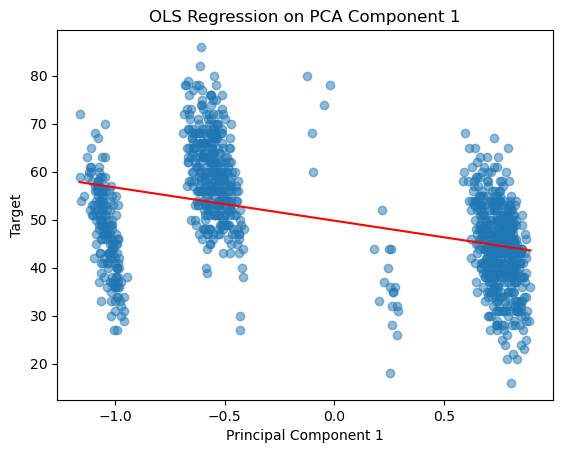

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import statsmodels.api as sm

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train[significant_predictors])

# Regression on PC1 only
X_pc1 = sm.add_constant(X_pca[:, 0])
model = sm.OLS(y_train, X_pc1).fit()

# predictions for line
x_line = np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 100)
y_line = model.predict(sm.add_constant(x_line))

# plot
plt.figure()
plt.scatter(X_pca[:, 0], y_train, alpha=0.5)
plt.plot(x_line, y_line, color="red")

plt.xlabel("Principal Component 1")
plt.ylabel("Target")
plt.title("OLS Regression on PCA Component 1")
plt.show()